# Fashion-MNIST ile Evrişimli Sinir Ağı (CNN) Görüntü Tahmin Projesi

Bu projede, derin öğrenme dünyasında bilgisayarlı görü (Computer Vision) çalışmalarının temel taşlarından biri olan **Fashion-MNIST** veri seti kullanılmıştır. Projenin temel amacı, ham kıyafet görsellerini yapay sinir ağlarına besleyerek modelin görsel içerik hakkında **çoklu sınıflandırma ve canlı tahmin (prediction)** yapmasını sağlamaktır.

### Proje Akışı ve Mimari Özeti:
*   **Veri Seti:** 10 farklı kategoride (T-shirt, çanta, ayakkabı vb.) 70.000 adet 28x28 piksel çözünürlüğünde gri tonlamalı görsel içermektedir.
*   **Ön İşleme:** Piksel değerleri modelin kararlı öğrenmesi için `0-1` arasına normalize edilmiştir.
*   **Model Mimarisi:** Görsellerdeki kenar, doku ve geometrik şekilleri yakalamak amacıyla **2 katmanlı Evrişimli Sinir Ağı (CNN)** mimarisi (`Conv2D` ve `MaxPooling2D`) kurulmuştur.
*   **Tahmin Mekanizması:** Çıktı katmanında kullanılan `Softmax` aktivasyon fonksiyonu sayesinde model, sisteme verilen yeni bir görselin hangi kıyafete ait olduğunu olasılıksal olarak **tahmin (prediction)** etmektedir.

In [1]:

# GEREKLİ KÜTÜPHANELERİN YÜKLENMESİ VE DONANIM KONTROLÜ

print(">> 1. Aşama: Temel kütüphaneler projeye dahil ediliyor...")
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential

print(f"TensorFlow Versiyonu: {tf.__version__}")

# Colab üzerinde GPU (Ekran Kartı) hızlandırıcısının açık olup olmadığını kontrol ediyoruz
print("\n>> 2. Aşama: Donanım kontrolü yapılıyor...")
gpu_devices = tf.config.list_physical_devices("GPU")

if len(gpu_devices) > 0:
    print(
        f"BAŞARILI: Model eğitimi için GPU aktif! Kullanılacak cihaz: {gpu_devices[0]}"
    )
else:
    print(
        "BİLGİ: GPU bulunamadı, eğitim CPU üzerinden yapılacak.\n(Daha hızlı eğitim için Colab menüsünden: Düzenle > Not Defteri Ayarları > Donanım Hızlandırıcı -> T4 GPU seçebilirsiniz.)"
    )

print("\n[ADIM 1 TAMAMLANDI] Çalışma ortamı hazır!")

>> 1. Aşama: Temel kütüphaneler projeye dahil ediliyor...
TensorFlow Versiyonu: 2.20.0

>> 2. Aşama: Donanım kontrolü yapılıyor...
BİLGİ: GPU bulunamadı, eğitim CPU üzerinden yapılacak.
(Daha hızlı eğitim için Colab menüsünden: Düzenle > Not Defteri Ayarları > Donanım Hızlandırıcı -> T4 GPU seçebilirsiniz.)

[ADIM 1 TAMAMLANDI] Çalışma ortamı hazır!


In [2]:
# VERİ SETİNİN YÜKLENMESİ VE ÖN İŞLEME (PREPROCESSING)

print(">> Veri seti indiriliyor...")
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# 10 farklı kıyafet sınıfının sözel karşılıkları
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print(">> Veriler normalize ediliyor (0-255 arası -> 0.0-1.0 arası)...")
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(">> Matis boyutları CNN mimarisine uygun hale getiriliyor...")
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

print("\n[ADIM 2 TAMAMLANDI] Veri hazırlığı bitti!")
print(f"Eğitim Seti Boyutu: {X_train.shape} | Test Seti Boyutu: {X_test.shape}")

>> Veri seti indiriliyor...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
>> Veriler normalize ediliyor (0-255 arası -> 0.0-1.0 arası)...
>> Matis boyutları CNN mimarisine uygun hale getiriliyor...

[ADIM 2 TAMAMLANDI] Veri hazırlığı bitti!
Eğitim Seti Boyutu: (60000, 28, 28, 1) | Test Seti Boyutu: (10000, 28, 28, 1)


In [3]:
# CNN MODEL MİMARİSİNİN TASARLANMASI VE DERLENMESİ

print(">> Evrişimli Sinir Ağı (CNN) katmanları oluşturuluyor...\n")

model = Sequential(
    [
        # 1. Evrişim Bloku
        Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        # 2. Evrişim Bloku
        Conv2D(64, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        # Düzleştirme ve Tam Bağlantılı (Dense) Katmanlar
        Flatten(),
        Dense(128, activation="relu"),
        # Çıktı Katmanı (10 sınıfın olasılık tahmini için Softmax)
        Dense(10, activation="softmax"),
    ]
)

# Çoklu sınıflandırma (Multi-class) için en kararlı optimizasyon ayarları
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("[ADIM 3 TAMAMLANDI] Model mimarisi başarıyla kuruldu. Model özeti:")
model.summary()

>> Evrişimli Sinir Ağı (CNN) katmanları oluşturuluyor...

[ADIM 3 TAMAMLANDI] Model mimarisi başarıyla kuruldu. Model özeti:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

>> Yapay sinir ağı eğitimi başlatıldı. Lütfen bekleyin...

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - accuracy: 0.8229 - loss: 0.4958 - val_accuracy: 0.8718 - val_loss: 0.3552
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 85s 56ms/step - accuracy: 0.8821 - loss: 0.3244 - val_accuracy: 0.8913 - val_loss: 0.3018
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.8979 - loss: 0.2811 - val_accuracy: 0.9022 - val_loss: 0.2772
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9092 - loss: 0.2497 - val_accuracy: 0.9010 - val_loss: 0.2696
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 52ms/step - accuracy: 0.9177 - loss: 0.2233 - val_accuracy: 0.9112 - val_loss: 0.2524

>> Eğitim tamamlandı! Doğruluk ve Kayıp grafikleri çiziliyor...


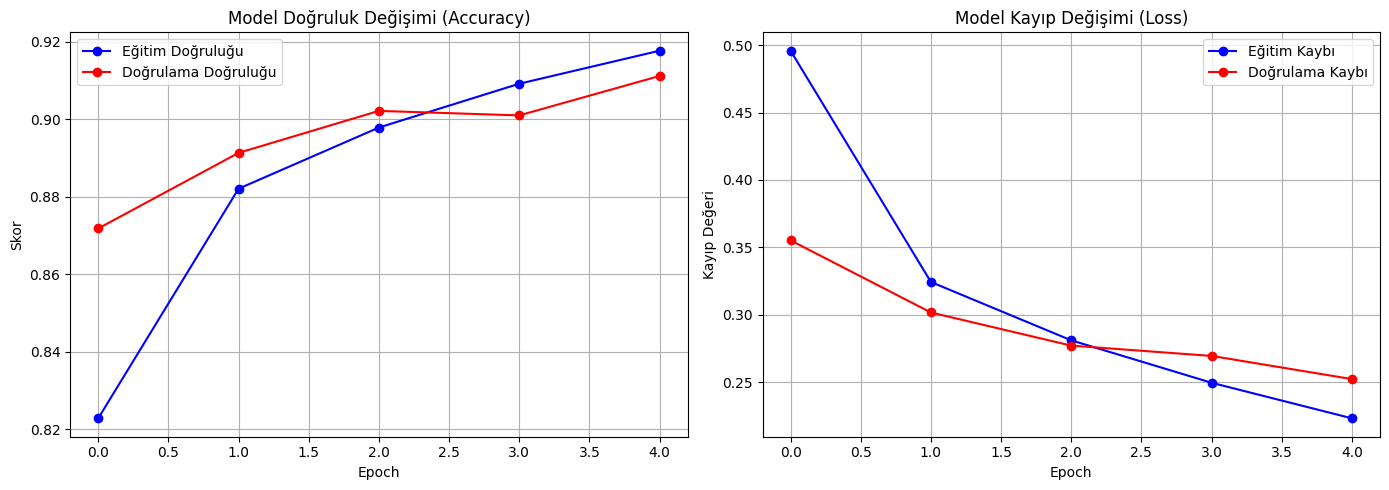

[ADIM 4 TAMAMLANDI] Modelin eğitim geçmişi yukarıdaki grafiklerde görselleştirilmiştir.


In [4]:
# MODELİN EĞİTİLMESİ VE BAŞARI GRAFİKLERİ

print(">> Yapay sinir ağı eğitimi başlatıldı. Lütfen bekleyin...\n")

# Modelin fit edilmesi
history = model.fit(
    X_train, y_train, epochs=5, batch_size=64, validation_split=0.1
)

print("\n>> Eğitim tamamlandı! Doğruluk ve Kayıp grafikleri çiziliyor...")

# Grafiklerin ekrana basılması
plt.figure(figsize=(14, 5))

# Doğruluk Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], "b-o", label="Eğitim Doğruluğu")
plt.plot(history.history["val_accuracy"], "r-o", label="Doğrulama Doğruluğu")
plt.title("Model Doğruluk Değişimi (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Skor")
plt.legend()
plt.grid(True)

# Kayıp Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], "b-o", label="Eğitim Kaybı")
plt.plot(history.history["val_loss"], "r-o", label="Doğrulama Kaybı")
plt.title("Model Kayıp Değişimi (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Kayıp Değeri")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(
    "[TAMAMLANDI] Modelin eğitim geçmişi yukarıdaki grafiklerde görselleştirilmiştir."
)

>> Model, daha önce hiç karşılaşmadığı test verileriyle sınanıyor...

 PROJE DOĞRULUK SKORU (TEST ACCURACY): %90.18



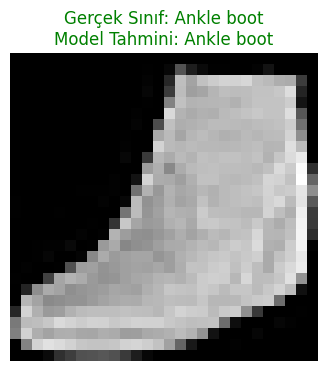

[ TAMAMLANDI] Tebrikler! Tüm proje adımları başarıyla koşturuldu.


In [9]:
# FİNAL TESTİ VE RASTGELE GÖRSEL ÜZERİNDE TAHMİN (PREDICTION)

print(">> Model, daha önce hiç karşılaşmadığı test verileriyle sınanıyor...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("\n" + "=" * 55)
print(f" PROJE DOĞRULUK SKORU (TEST ACCURACY): %{test_acc * 100:.2f}")
print("=" * 55 + "\n")

# Test veri setinden rastgele bir resim seçip modelin tahmin gücünü görselleştirme
rastgele_id = np.random.randint(0, len(X_test))
test_resmi = X_test[rastgele_id]
gercek_sinif_id = y_test[rastgele_id]

# Model tahmini (Boyutu model girdisine uydurmak için expand_dims yapıyoruz)
tahmin_skorlari = model.predict(np.expand_dims(test_resmi, axis=0), verbose=0)
tahmin_sinif_id = np.argmax(tahmin_skorlari)

# Tahmin sonucunu görsel olarak bastırma
plt.figure(figsize=(4, 4))
plt.imshow(test_resmi.squeeze(), cmap="gray")
baslik_rengi = "green" if gercek_sinif_id == tahmin_sinif_id else "red"

plt.title(
    f"Gerçek Sınıf: {class_names[gercek_sinif_id]}\nModel Tahmini: {class_names[tahmin_sinif_id]}",
    color=baslik_rengi,
    fontsize=12,
)
plt.axis("off")
plt.show()

print(
    f"[ TAMAMLANDI] Tebrikler! Tüm proje adımları başarıyla koşturuldu."
)